In [ ]:
# try increasing the inputs of the hidden layer
# change the embedding dim
# change the amount of chars inputted
# try changing batch sizes
# try changin learning rate and how it decays
# read bengio et. al.

'''
Didn't really get too good values even though i played around with the params more than
what is in the results. Also, i torched both my GPU and my a** running these, so i didn't
run too many iterations on this. The 'names' the model outputs actually start to look good
never the less, i got Sandra and Shania for the ladies, and Brick for the dudes.
'''

In [285]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import clear_output

In [62]:
words = open('names.txt', 'r').read().splitlines()

In [63]:

chars = sorted(set(list(''.join(words))))

stoi = {c: i+1 for i, c in enumerate(chars)}
stoi['.'] = 0
itos = {i: c for c, i in stoi.items()}

In [504]:
# build the datasets
block_size = 3
def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182551, 3]) torch.Size([182551])
torch.Size([22783, 3]) torch.Size([22783])
torch.Size([22812, 3]) torch.Size([22812])


In [524]:
# create the embedding table, try different embedding dims
embedding_dim = 10
hidden_size = 500
batch_size = 64
learning_rate = 0.1

C = torch.rand(27, embedding_dim)
emb = C[Xtr]
print('raw emb table shape: ', emb.shape)
emb = emb.view(-1, block_size * emb.shape[2])
print('embeddings shape: ', emb.shape)
# initialize the network

g = torch.Generator().manual_seed(42)

W1 = torch.randn((emb.shape[1], hidden_size), generator=g)
b1 = torch.randn(hidden_size, generator=g)
W2 = torch.randn((hidden_size, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]
num_params = sum(p.nelement() for p in parameters)
for p in parameters:
    p.requires_grad = True

print('num params: ', num_params)

raw emb table shape:  torch.Size([182551, 3, 10])
embeddings shape:  torch.Size([182551, 30])
num params:  29297


In [525]:
lre = torch.linspace(-1, 0, 1000)
lrs = 10**lre

In [526]:
lri = []
lossi = []
n = []

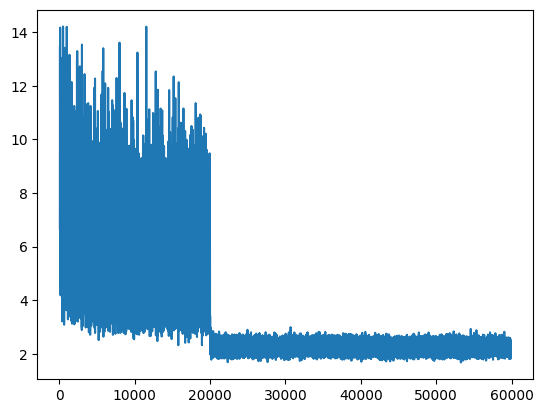

In [527]:


for i in range(1, 60000):
    # mini-batch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))

    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, block_size * emb.shape[2]) @ W1 + b1)
    logits = (h @ W2 + b2)

    # loss
    loss = F.cross_entropy(logits, Ytr[ix])

    # backwards pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update values
    if i < 20000:
        lr = lr1 = 0.1
    elif i < 40000:
        lr = lr2 = 0.01
    else:
        lr = lr3 = 0.001

    for p in parameters:
        p.data += -lr * p.grad
    
    # track states
    #lri.append(lre[i])
    lossi.append(loss.item())
    n.append(i)

    if i % 100 == 0:
        clear_output(wait=True)
        plt.plot(n[90:], lossi[90:])
        plt.show()
    if loss.item() < 1.4:
        break


In [528]:
# check the loss for the whole dataset

emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, block_size * emb.shape[2]) @ W1 + b1)
logits = h @ W2 + b2
# loss
losstr = F.cross_entropy(logits, Ytr)
losstr

tensor(2.2287, grad_fn=<NllLossBackward0>)

In [529]:
# check the loss for the whole dataset

emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, block_size * emb.shape[2]) @ W1 + b1)
logits = h @ W2 + b2
# loss
lossdev = F.cross_entropy(logits, Ydev)
lossdev

tensor(2.2534, grad_fn=<NllLossBackward0>)

In [ ]:
tr_set = 0 # not the best place to put this...

In [ ]:
tr_set += 1

output = f'''
Training set:...............{tr_set}
Block size:.................{block_size}
Embedding dim:..............{embedding_dim}
Hidden layer size:..........{hidden_size}
Batch size:.................{batch_size}
Learning rate:..............{learning_rate}
Training loss finish:.......{lossi[-1]}
Iterations:.................{n[-1]}
Trainingset loss:...........{losstr.item()}
Devset loss:................{lossdev.item()}
'''

with open('results_lesson2_ex.txt', 'a') as file:
    file.write(output)

In [531]:
# sample from the dataset with the model

for i in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        emb = C[torch.tensor([context])] # (1, block_size, d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

shania.
keuh.
raree.
thara.
hae.
haxnon.
aam.
khalny.
dan.
milen.
loynlyson.
jaisen.
oaneth.
brick.
nieghaley.
nosx.
mor.
karays.
aquievan.
xorberrin.
